# Linear Systems — The Mathematics of Stateful AI

## From 1D to 2D: New Degrees of Freedom

In one-dimensional phase spaces, trajectories are forced to move monotonically or remain constant. In two dimensions, trajectories have **room to maneuver** — spirals, closed orbits, saddle points, and nodes all become possible.

The governing equation for a 2D linear system is:

$$\dot{\mathbf{x}} = A\mathbf{x}, \quad \text{where } A = \begin{pmatrix} a & b \\ c & d \end{pmatrix}, \quad \mathbf{x} = \begin{pmatrix} x \\ y \end{pmatrix}$$

This is the simplest class of higher-dimensional systems, yet it plays a **central role** in classifying fixed points of nonlinear systems (as we'll see in later chapters).

---

While the Transformer era was dominated by stateless, autoregressive pattern matching, the next frontier — **State-Space Models** (S4, Mamba) and **Causal World Models** — is effectively an engineering application of 2D linear systems.

The core equation of a State-Space Model is:

$$\dot{\mathbf{h}}(t) = A\mathbf{h}(t) + B\mathbf{u}(t)$$

This is **exactly** the $\dot{\mathbf{x}} = A\mathbf{x}$ from this chapter, with an input term added.

> **The "Aha!" Moment**: Every layer in a deep network is a single "time-step" in a dynamical flow. Training the network is the process of **shaping the $A$ matrix** of those flows so that "Correct Answers" become **Global Attractors**.

---

# 5.1 Definitions and Examples

## The Two-Dimensional Linear System

A 2D linear system has the form:

$$\dot{x} = ax + by$$
$$\dot{y} = cx + dy$$

In matrix notation: $\dot{\mathbf{x}} = A\mathbf{x}$.

Key properties:
- The system is **linear**: if $\mathbf{x}_1$ and $\mathbf{x}_2$ are solutions, so is $c_1\mathbf{x}_1 + c_2\mathbf{x}_2$.
- $\mathbf{x}^* = \mathbf{0}$ is **always** a fixed point for any choice of $A$.
- Trajectories in the $(x, y)$ plane form the **phase portrait**.

---

## Example: The Simple Harmonic Oscillator

The vibrations of a mass on a spring: $m\ddot{x} + kx = 0$.

Rewriting with $v = \dot{x}$ and $\omega^2 = k/m$:

$$\dot{x} = v$$
$$\dot{v} = -\omega^2 x$$

The matrix is $A = \begin{pmatrix} 0 & 1 \\ -\omega^2 & 0 \end{pmatrix}$.

The origin is a **center** — trajectories form **closed orbits** (ellipses), corresponding to periodic oscillations.

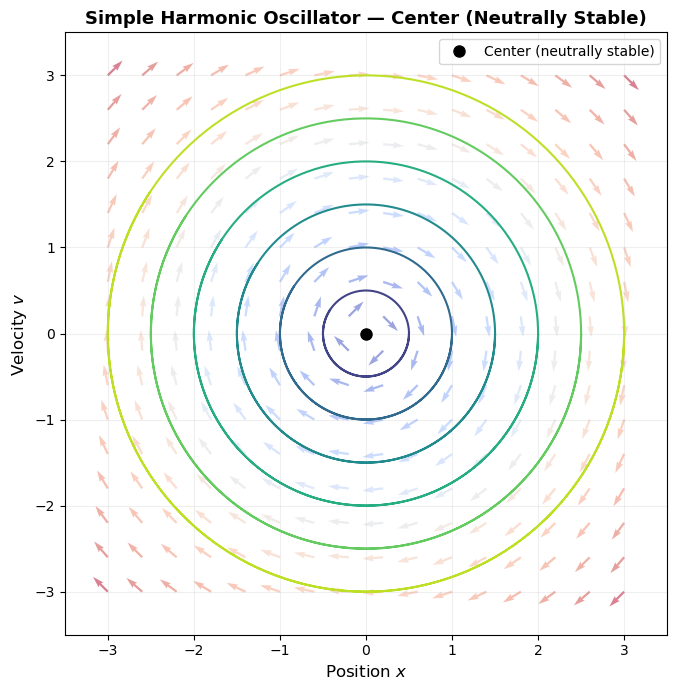


Key Observations:
  • Trajectories form CLOSED ORBITS (ellipses) — periodic motion.
  • The origin is a CENTER: neutrally stable (Liapunov stable but not attracting).
  • A particle placed at the origin stays forever (fixed point).
  • Any perturbation leads to perpetual oscillation, never growing or shrinking.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ─────────────────────────────────────────────────────────────────
# Simple Harmonic Oscillator: Phase Portrait
# ẋ = v,  v̇ = -ω²x   (center)
# ─────────────────────────────────────────────────────────────────

omega = 1.0

def sho(t, state):
    x, v = state
    return [v, -omega**2 * x]

fig, ax = plt.subplots(figsize=(7, 7))

# Vector field
xs = np.linspace(-3, 3, 16)
vs = np.linspace(-3, 3, 16)
X, V = np.meshgrid(xs, vs)
dX = V
dV = -omega**2 * X
mag = np.sqrt(dX**2 + dV**2)
ax.quiver(X, V, dX/mag, dV/mag, mag, cmap='coolwarm', alpha=0.5)

# Trajectories from different initial conditions
colors = plt.cm.viridis(np.linspace(0.2, 0.9, 6))
for i, r0 in enumerate([0.5, 1.0, 1.5, 2.0, 2.5, 3.0]):
    sol = solve_ivp(sho, [0, 10], [r0, 0], t_eval=np.linspace(0, 10, 500), max_step=0.01)
    ax.plot(sol.y[0], sol.y[1], color=colors[i], lw=1.5)

ax.plot(0, 0, 'ko', ms=8, zorder=5, label='Center (neutrally stable)')
ax.set_xlabel('Position $x$', fontsize=12)
ax.set_ylabel('Velocity $v$', fontsize=12)
ax.set_title('Simple Harmonic Oscillator — Center (Neutrally Stable)', fontsize=13, fontweight='bold')
ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.5, 3.5)
ax.set_aspect('equal')
ax.legend(fontsize=10)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("""
Key Observations:
  • Trajectories form CLOSED ORBITS (ellipses) — periodic motion.
  • The origin is a CENTER: neutrally stable (Liapunov stable but not attracting).
  • A particle placed at the origin stays forever (fixed point).
  • Any perturbation leads to perpetual oscillation, never growing or shrinking.
""")

## Stability Language

These definitions are crucial for classifying fixed points in both dynamical systems and AI:

| Term | Definition | AI Analogy |
|---|---|---|
| **Attracting** | All nearby trajectories → $\mathbf{x}^*$ as $t → \infty$ | Convergence to a learned representation |
| **Liapunov Stable** | Nearby trajectories *stay* near $\mathbf{x}^*$ for all time | Signal doesn't explode |
| **Neutrally Stable** | Liapunov stable but NOT attracting | Perfect information preservation (ideal LSTM) |
| **Asymptotically Stable** | Both Liapunov stable AND attracting | Gradient descent converging to a minimum |
| **Unstable** | Neither attracting nor Liapunov stable | Gradient explosion, NaN loss |

> **Talking Point**: Ask yourself — *"Will the system forget a perturbation (stable), hold it forever (neutral), or amplify it (unstable)?"* This directly maps to how neural networks process signals through layers.

---

# The Geometry of Signal Flow — Eigen-Logic for Everyone

Before diving into the classification, let's build an **intuitive picture** of eigenvalues and eigenvectors.

## The Room Analogy

Imagine a signal (a thought, a feature) passing through a deep neural network. Each layer is like a **room with several fans blowing in different directions**.

### Eigenvectors are the "Preferred Directions"

In every "room" (layer), there are specific directions where the fans are blowing **perfectly straight**. If a signal enters aligned with an **eigenvector**, it won't be pushed left or right — it will just stay on that path.

Mathematically: if $\mathbf{v}$ is an eigenvector of $A$, then $A\mathbf{v} = \lambda \mathbf{v}$ — multiplication by $A$ doesn't change the *direction*, only the *magnitude*.

### Eigenvalues are the "Volume Knobs"

For each preferred direction (eigenvector), the **eigenvalue** $\lambda$ tells you how much the signal is amplified or muffled:

| $\lambda$ | Effect per layer | After 50 layers | Regime |
|---|---|---|---|
| $\lambda = 2.0$ | Signal **doubles** | $2^{50} \approx 10^{15}$ — astronomical | **Exploding Gradient** |
| $\lambda = 0.5$ | Signal **halved** | $0.5^{50} \approx 10^{-15}$ — gone | **Vanishing Gradient** |
| $\lambda = 1.0$ | Signal **preserved** | $1^{50} = 1$ — perfect | **Goldilocks Zone** |

### The Goldilocks Zone

The entire architecture of modern recurrent networks — **LSTM gates**, **GRU update gates**, **SSM HiPPO matrices** — is an exercise in **eigenvalue engineering**: placing eigenvalues at exactly the right positions to control memory decay.

- **LSTMs** achieve $\lambda = 1$ via the "forget gate" — when the gate is fully open, the cell state is multiplied by exactly 1.
- **Mamba/S4** achieve this via the **HiPPO matrix** — a specific $A$ matrix whose eigenvalues are designed to sit on the stable boundary.

---

# 5.2 Classification of Linear Systems

## The Eigensolution

We seek straight-line trajectories of the form $\mathbf{x}(t) = e^{\lambda t}\mathbf{v}$.

Substituting into $\dot{\mathbf{x}} = A\mathbf{x}$ gives $A\mathbf{v} = \lambda\mathbf{v}$ — the eigenvalue problem.

For a $2\times 2$ matrix, the **characteristic equation** is:

$$\lambda^2 - \tau\lambda + \Delta = 0$$

where:
- $\tau = \text{tr}(A) = a + d$ — the **trace** (sum of eigenvalues)
- $\Delta = \det(A) = ad - bc$ — the **determinant** (product of eigenvalues)

The eigenvalues are:

$$\lambda_{1,2} = \frac{\tau \pm \sqrt{\tau^2 - 4\Delta}}{2}$$

The general solution (for distinct eigenvalues) is:

$$\mathbf{x}(t) = c_1 e^{\lambda_1 t}\mathbf{v}_1 + c_2 e^{\lambda_2 t}\mathbf{v}_2$$

---

## The Jacobian as a "Local Snapshot"

In real AI systems, the dynamics are usually **nonlinear**: $\dot{\mathbf{x}} = \mathbf{f}(\mathbf{x})$.

But near a fixed point $\mathbf{x}^*$, we can take a **local linear approximation** — the Jacobian matrix $J = D\mathbf{f}(\mathbf{x}^*)$. This Jacobian IS the matrix $A$ from our linear theory.

> **Causal Relevance**: In a World Model (DreamerV3, JEPA), the "physics" is nonlinear. But to check if the model's imagination is stable *at a specific moment*, we compute the Jacobian. If it shows a **Stable Node**, we can trust the next few steps of the rollout.

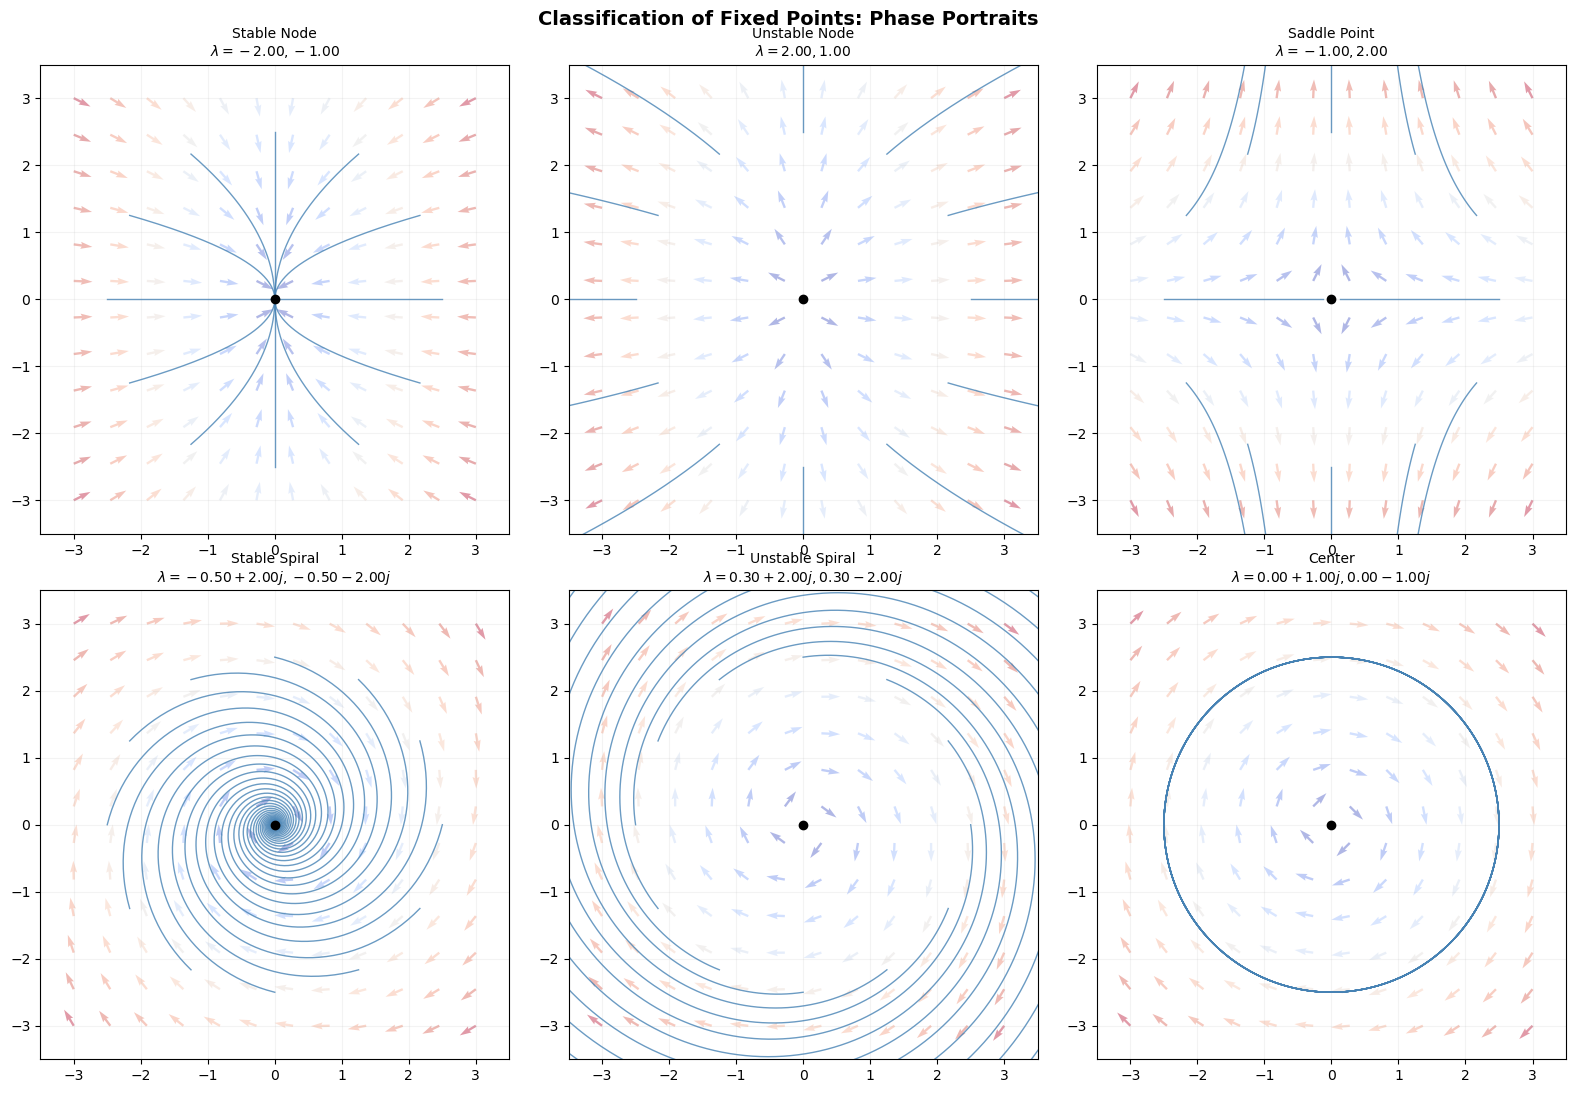


Reading the Phase Portraits:
  • STABLE NODE: all trajectories converge to origin (both eigenvalues negative real).
  • UNSTABLE NODE: all trajectories flee the origin (both eigenvalues positive real).
  • SADDLE POINT: attracting in one direction, repelling in another (opposite-sign eigenvalues).
  • STABLE SPIRAL: oscillatory convergence (complex eigenvalues, negative real part).
  • UNSTABLE SPIRAL: oscillatory divergence (complex eigenvalues, positive real part).
  • CENTER: perpetual oscillation (pure imaginary eigenvalues).



In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ─────────────────────────────────────────────────────────────────
# Phase Portraits for ALL Major Fixed-Point Types
# ─────────────────────────────────────────────────────────────────

def linear_system(t, state, A):
    return A @ state

def plot_phase_portrait(ax, A, title, t_span=(0, 10)):
    """Plot vector field + trajectories for ẋ = Ax."""
    # Vector field
    xs = np.linspace(-3, 3, 12)
    ys = np.linspace(-3, 3, 12)
    X, Y = np.meshgrid(xs, ys)
    dX = A[0, 0]*X + A[0, 1]*Y
    dY = A[1, 0]*X + A[1, 1]*Y
    mag = np.sqrt(dX**2 + dY**2)
    mag[mag == 0] = 1
    ax.quiver(X, Y, dX/mag, dY/mag, mag, cmap='coolwarm', alpha=0.4, scale=25)

    # Trajectories
    angles = np.linspace(0, 2*np.pi, 12, endpoint=False)
    r0 = 2.5
    for theta in angles:
        x0 = [r0*np.cos(theta), r0*np.sin(theta)]
        try:
            sol = solve_ivp(linear_system, t_span, x0, args=(A,),
                           t_eval=np.linspace(*t_span, 500), max_step=0.02)
            # Clip to visible range
            mask = (np.abs(sol.y[0]) < 5) & (np.abs(sol.y[1]) < 5)
            ax.plot(sol.y[0][mask], sol.y[1][mask], 'steelblue', lw=1, alpha=0.8)
        except:
            pass

    # Eigenvalues
    eigvals = np.linalg.eigvals(A)
    ev_str = ', '.join([f'{e:.2f}' for e in eigvals])

    ax.plot(0, 0, 'ko', ms=6, zorder=5)
    ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.5, 3.5)
    ax.set_aspect('equal')
    ax.set_title(f'{title}\n$\\lambda = {ev_str}$', fontsize=10)
    ax.grid(alpha=0.15)

# Define matrices for each type
cases = [
    (np.array([[-2, 0], [0, -1]]),       'Stable Node',       (0, 5)),
    (np.array([[2, 0], [0, 1]]),          'Unstable Node',     (0, 2)),
    (np.array([[-1, 0], [0, 2]]),         'Saddle Point',      (0, 3)),
    (np.array([[-0.5, 2], [-2, -0.5]]),   'Stable Spiral',     (0, 12)),
    (np.array([[0.3, 2], [-2, 0.3]]),     'Unstable Spiral',   (0, 8)),
    (np.array([[0, 1], [-1, 0]]),         'Center',            (0, 8)),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 11))
fig.suptitle('Classification of Fixed Points: Phase Portraits', fontsize=14, fontweight='bold')

for ax, (A, title, tspan) in zip(axes.flat, cases):
    plot_phase_portrait(ax, A, title, tspan)

plt.tight_layout()
plt.show()

print("""
Reading the Phase Portraits:
  • STABLE NODE: all trajectories converge to origin (both eigenvalues negative real).
  • UNSTABLE NODE: all trajectories flee the origin (both eigenvalues positive real).
  • SADDLE POINT: attracting in one direction, repelling in another (opposite-sign eigenvalues).
  • STABLE SPIRAL: oscillatory convergence (complex eigenvalues, negative real part).
  • UNSTABLE SPIRAL: oscillatory divergence (complex eigenvalues, positive real part).
  • CENTER: perpetual oscillation (pure imaginary eigenvalues).
""")

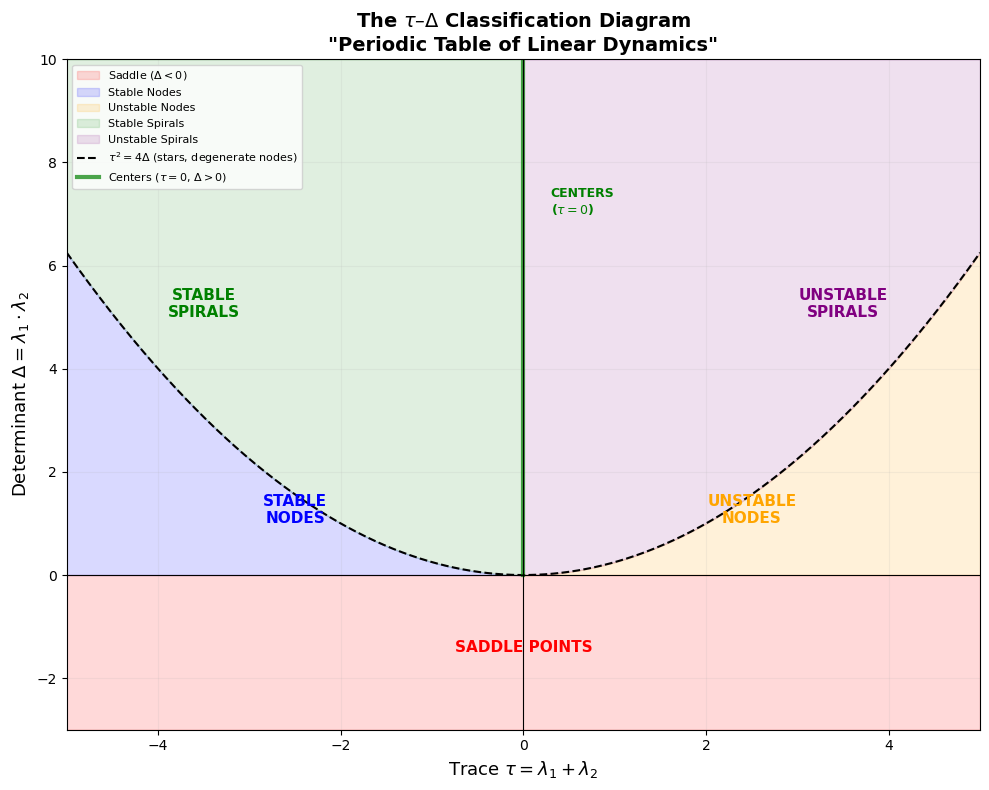


The τ–Δ Diagram — "Periodic Table of Linear Dynamics":

  • Δ < 0 → SADDLE POINT (eigenvalues have opposite signs).
  • Δ > 0, below parabola → NODES (real eigenvalues, same sign).
  • Δ > 0, above parabola → SPIRALS (complex eigenvalues).
  • τ < 0 → STABLE (eigenvalues have negative real part).
  • τ > 0 → UNSTABLE (eigenvalues have positive real part).
  • τ = 0 → CENTERS (pure imaginary eigenvalues, neutrally stable).
  • Parabola τ² = 4Δ → STARS and DEGENERATE NODES (borderline).

This single diagram classifies ALL possible behaviors of 2D linear systems!



In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─────────────────────────────────────────────────────────────────
# The τ–Δ Classification Diagram ("Periodic Table" of 2D Flows)
# ─────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 8))

tau = np.linspace(-5, 5, 1000)
parabola = tau**2 / 4

# Fill regions
# Saddle: Δ < 0
ax.fill_between(tau, -3, 0, alpha=0.15, color='red', label='Saddle ($\\Delta < 0$)')

# Stable nodes: Δ > 0, τ < 0, τ² > 4Δ  (below parabola, left side)
ax.fill_between(tau[tau < 0], 0, parabola[tau < 0], alpha=0.15, color='blue',
                label='Stable Nodes', where=parabola[tau < 0] <= 10)

# Unstable nodes: Δ > 0, τ > 0, τ² > 4Δ (below parabola, right side)
ax.fill_between(tau[tau > 0], 0, parabola[tau > 0], alpha=0.15, color='orange',
                label='Unstable Nodes', where=parabola[tau > 0] <= 10)

# Stable spirals: Δ > 0, τ < 0, τ² < 4Δ (above parabola, left)
ax.fill_between(tau[tau < 0], parabola[tau < 0], 10, alpha=0.12, color='green',
                label='Stable Spirals', where=parabola[tau < 0] <= 10)

# Unstable spirals: Δ > 0, τ > 0, τ² < 4Δ (above parabola, right)
ax.fill_between(tau[tau > 0], parabola[tau > 0], 10, alpha=0.12, color='purple',
                label='Unstable Spirals', where=parabola[tau > 0] <= 10)

# Parabola: τ² = 4Δ (border between nodes and spirals)
ax.plot(tau, parabola, 'k--', lw=1.5, label='$\\tau^2 = 4\\Delta$ (stars, degenerate nodes)')

# Centers: τ = 0, Δ > 0
ax.plot([0, 0], [0, 10], 'g-', lw=3, alpha=0.7, label='Centers ($\\tau = 0$, $\\Delta > 0$)')

# Annotations
ax.text(-3.5, 5, 'STABLE\nSPIRALS', fontsize=11, fontweight='bold', color='green', ha='center')
ax.text(3.5, 5, 'UNSTABLE\nSPIRALS', fontsize=11, fontweight='bold', color='purple', ha='center')
ax.text(-2.5, 1.0, 'STABLE\nNODES', fontsize=11, fontweight='bold', color='blue', ha='center')
ax.text(2.5, 1.0, 'UNSTABLE\nNODES', fontsize=11, fontweight='bold', color='orange', ha='center')
ax.text(0, -1.5, 'SADDLE POINTS', fontsize=11, fontweight='bold', color='red', ha='center')
ax.text(0.3, 7, 'CENTERS\n($\\tau=0$)', fontsize=9, fontweight='bold', color='green')

ax.set_xlabel('Trace $\\tau = \\lambda_1 + \\lambda_2$', fontsize=13)
ax.set_ylabel('Determinant $\\Delta = \\lambda_1 \\cdot \\lambda_2$', fontsize=13)
ax.set_title('The $\\tau$–$\\Delta$ Classification Diagram\n"Periodic Table of Linear Dynamics"',
             fontsize=14, fontweight='bold')
ax.set_xlim(-5, 5); ax.set_ylim(-3, 10)
ax.axhline(0, color='black', lw=0.8)
ax.axvline(0, color='black', lw=0.8)
ax.legend(fontsize=8, loc='upper left')
ax.grid(alpha=0.15)

plt.tight_layout()
plt.show()

print("""
The τ–Δ Diagram — "Periodic Table of Linear Dynamics":

  • Δ < 0 → SADDLE POINT (eigenvalues have opposite signs).
  • Δ > 0, below parabola → NODES (real eigenvalues, same sign).
  • Δ > 0, above parabola → SPIRALS (complex eigenvalues).
  • τ < 0 → STABLE (eigenvalues have negative real part).
  • τ > 0 → UNSTABLE (eigenvalues have positive real part).
  • τ = 0 → CENTERS (pure imaginary eigenvalues, neutrally stable).
  • Parabola τ² = 4Δ → STARS and DEGENERATE NODES (borderline).

This single diagram classifies ALL possible behaviors of 2D linear systems!
""")

## The τ–Δ "Health Check" for AI Models

Here's a powerful idea: the τ–Δ diagram isn't just a textbook classification — it's a **Model Health Monitor**.

During training, we can track the **Trace** and **Determinant** of our weight matrices (or the Jacobian of the network at various points). If the model starts moving from the **stable left side** of the diagram into the **unstable right side**, we know a **gradient explosion is imminent** — before it actually happens.

This is a more *scientific* approach to monitoring training than just watching the loss curve:

| τ–Δ Region | What it means for training |
|---|---|
| Stable Node (left, below parabola) | Gradients decay → learning slows (may need higher LR) |
| Stable Spiral (left, above parabola) | Gradients oscillate and decay → "hunting" for a minimum |
| Center (τ = 0) | Perfect information flow → the ideal |
| Unstable Spiral (right, above parabola) | Gradients oscillate and grow → loss oscillation, early divergence |
| Unstable Node (right, below parabola) | Gradients grow monotonically → NaN explosion |
| Saddle (Δ < 0) | Some directions grow, others shrink → training plateau |

---

# 5.3 Love Affairs — An Analog for Multi-Head Attention Interaction

Strogatz models the dynamics of Romeo and Juliet's love as a 2D linear system:

$$\dot{R} = aR + bJ, \quad \dot{J} = cR + dJ$$

where $R(t)$ and $J(t)$ are the love/hate of Romeo and Juliet for each other.

### The Structural Metaphor for Attention

If Romeo is **Head 1** and Juliet is **Head 2** in multi-head attention, their "love/hate" is the **causal influence** they exert on each other's latent representations:

- Coefficient $b$ = "How much does Juliet's state affect Romeo's derivative?" → **Cross-attention weight**.
- Coefficient $a$ = "How much does Romeo's own state affect his derivative?" → **Self-reinforcement / decay**.

The dynamics are completely determined by the eigenvalues of the matrix $\begin{pmatrix} a & b \\ c & d \end{pmatrix}$.

### Example: Two Cautious Lovers

If $a = d < 0$ (both cautious) and $b = c > 0$ (both responsive):

- $\Delta = a^2 - b^2$, $\tau = 2a < 0$.
- If $|a| > |b|$: **Stable node** → the relationship fizzles to mutual indifference (excessive caution → apathy).
- If $|a| < |b|$: **Saddle point** → the relationship is explosive (end up in a love fest or a war).

In attention terms: if the **self-decay** of each head dominates the **cross-influence**, the representations collapse to zero. If cross-influence dominates, the heads amplify each other — for better or worse.

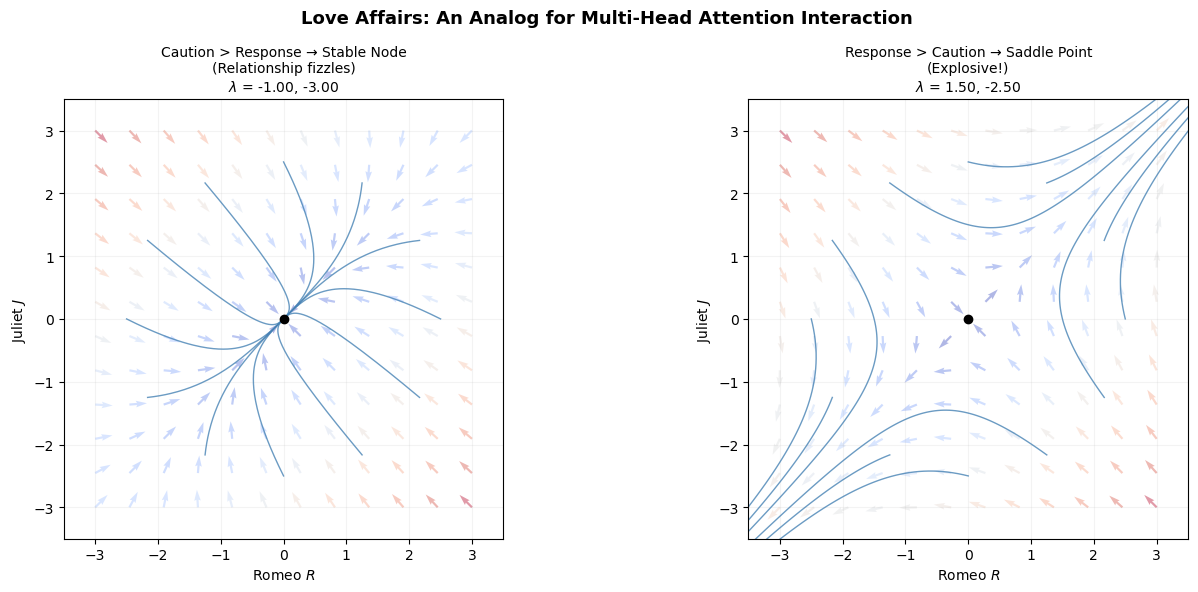

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ─────────────────────────────────────────────────────────────────
# Love Affairs: Two Cautious Lovers → Stable Node vs Saddle
# ─────────────────────────────────────────────────────────────────

def love_system(t, state, A):
    return A @ state

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Love Affairs: An Analog for Multi-Head Attention Interaction',
             fontsize=13, fontweight='bold')

# Case 1: |a| > |b| → Stable node (fizzles out)
a1, b1 = -2, 1
A1 = np.array([[a1, b1], [b1, a1]])

# Case 2: |a| < |b| → Saddle (explosive)
a2, b2 = -0.5, 2
A2 = np.array([[a2, b2], [b2, a2]])

for ax, A, label in zip(axes, [A1, A2],
                         ['Caution > Response → Stable Node\n(Relationship fizzles)',
                          'Response > Caution → Saddle Point\n(Explosive!)']):
    # Vector field
    xs = np.linspace(-3, 3, 12)
    ys = np.linspace(-3, 3, 12)
    X, Y = np.meshgrid(xs, ys)
    dX = A[0, 0]*X + A[0, 1]*Y
    dY = A[1, 0]*X + A[1, 1]*Y
    mag = np.sqrt(dX**2 + dY**2); mag[mag == 0] = 1
    ax.quiver(X, Y, dX/mag, dY/mag, mag, cmap='coolwarm', alpha=0.4, scale=25)

    # Trajectories
    for theta in np.linspace(0, 2*np.pi, 12, endpoint=False):
        x0 = [2.5*np.cos(theta), 2.5*np.sin(theta)]
        sol = solve_ivp(love_system, [0, 5], x0, args=(A,),
                       t_eval=np.linspace(0, 5, 300), max_step=0.02)
        mask = (np.abs(sol.y[0]) < 5) & (np.abs(sol.y[1]) < 5)
        ax.plot(sol.y[0][mask], sol.y[1][mask], 'steelblue', lw=1, alpha=0.8)

    eigvals = np.linalg.eigvals(A)
    ax.plot(0, 0, 'ko', ms=6, zorder=5)
    ax.set_xlabel('Romeo $R$'); ax.set_ylabel('Juliet $J$')
    ax.set_title(f'{label}\n$\\lambda$ = {eigvals[0]:.2f}, {eigvals[1]:.2f}', fontsize=10)
    ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.5, 3.5)
    ax.set_aspect('equal'); ax.grid(alpha=0.15)

plt.tight_layout()
plt.show()

---

# AI Deep Dive 1:State-Space Models — The $A$ Matrix IS the Memory

The most direct application of this is in modern AI is the **Mamba** (and S4) architecture.

$$\dot{\mathbf{h}}(t) = A\mathbf{h}(t) + B\mathbf{u}(t)$$

- **The matrix $A$** is the **exact** matrix from above. $\mathbf{h}(t)$ is the hidden state (the model's memory).
- The **eigenvalues** of $A$ dictate the **decay rate of memory**.

### Stability Analysis
- If $A$ has ANY eigenvalue with positive real part (Strogatz's "unstable node" or "source"), the hidden state $\mathbf{h}(t)$ **explodes** as sequence length increases.
- The **HiPPO matrix** was designed specifically to have eigenvalues that sit on the **Stable Node / Stable Spiral boundary** — ensuring the model remembers a long history without exploding or vanishing.

### What the τ–Δ Diagram Tells Us
For any SSM, check where $(\tau, \Delta)$ falls:
- **Left half** ($\tau < 0$) → stable memory that decays at rate $|\tau|/2$.
- **Above parabola** → oscillatory memory (useful for periodic signals).
- **Right half** ($\tau > 0$) → ⚠️ unstable — the model will blow up on long sequences.

---

# AI Deep Dive 2: The Eigenvalue Problem of Gradients

The infamous **vanishing and exploding gradient** problem is fundamentally a dynamical systems problem.

During backpropagation through time (BPTT), we repeatedly multiply by the Jacobian of the layer transition. After $T$ steps, the effective matrix is approximately $J^T$.

The eigendecomposition tells us that $J^T$ scales each eigendirection by $\lambda^T$:

| Dominant eigenvalue | After $T$ steps | Behavior | Phase Portrait |
|---|---|---|---|
| $|\lambda_{\max}| > 1$ | $\lambda^T \to \infty$ | **GRADIENT EXPLOSION** | Unstable Node |
| $|\lambda_{\max}| < 1$ | $\lambda^T \to 0$ | **GRADIENT VANISHING** | Stable Node (too stable!) |
| $|\lambda_{\max}| = 1$ | $\lambda^T = 1$ | **PERFECT FLOW** | Center |

### Gating = Eigenvalue Engineering

The **gating mechanism** in LSTMs is a way of manually forcing the effective eigenvalue to be exactly $\lambda = 1$ (center behavior). When the forget gate $f_t = 1$:

$$c_t = f_t \cdot c_{t-1} + i_t \cdot \tilde{c}_t = 1 \cdot c_{t-1} + \ldots$$

The cell state is multiplied by exactly 1 — **neutrally stable**, information flows without decay.

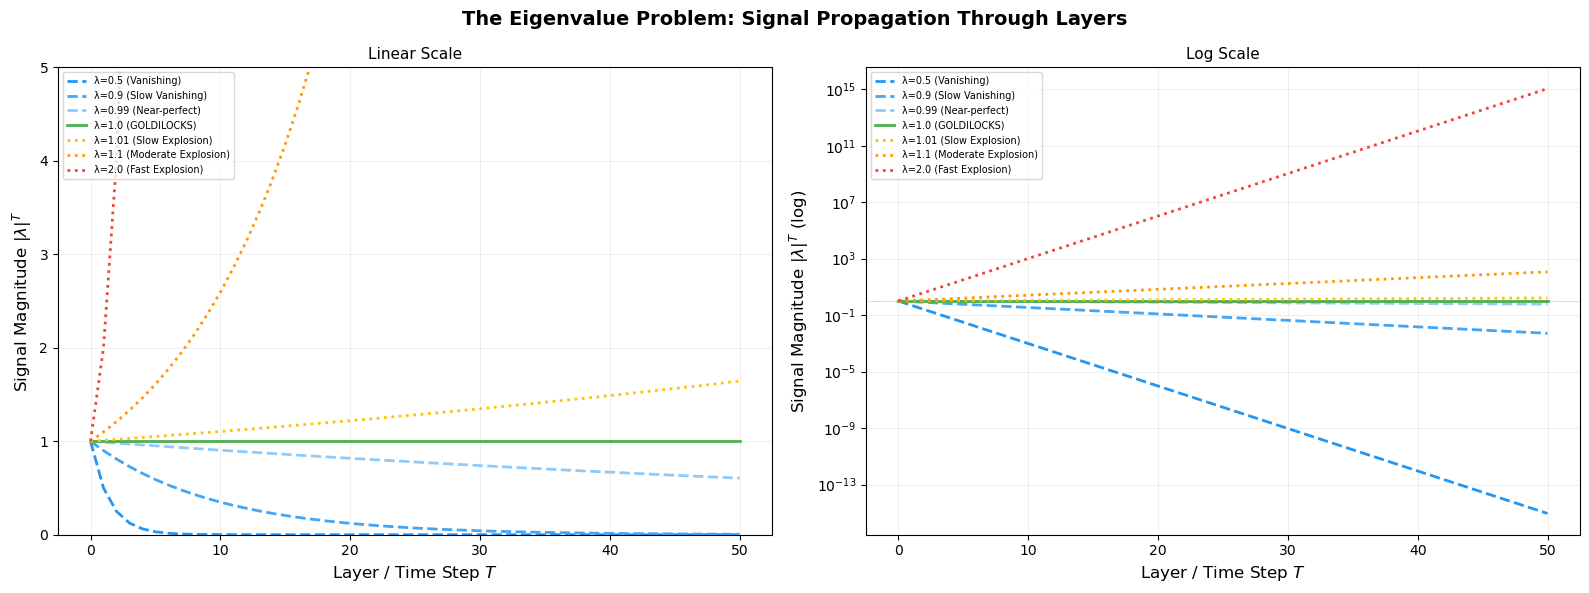


Reading the Plot:
  • GREEN (λ=1.0): The Goldilocks Zone — signal preserved perfectly across all layers.
  • BLUE (λ<1): Signal decays — VANISHING GRADIENT. The network forgets long-range info.
  • RED (λ>1): Signal explodes — EXPLODING GRADIENT. Training diverges (NaN loss).
  • Even small deviations from 1.0 (e.g., λ=1.01) compound over 50 layers!

This is WHY architectures like LSTMs and Mamba engineer eigenvalues to be near 1.



In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────
# Eigenvalue Magnitude vs Signal Propagation over T Steps
# Shows: Vanishing vs Exploding vs Goldilocks
# ─────────────────────────────────────────────────────────────────

T = np.arange(0, 51)
eigenvalues = [0.5, 0.9, 0.99, 1.0, 1.01, 1.1, 2.0]
labels = ['λ=0.5 (Vanishing)', 'λ=0.9 (Slow Vanishing)', 'λ=0.99 (Near-perfect)',
          'λ=1.0 (GOLDILOCKS)', 'λ=1.01 (Slow Explosion)', 'λ=1.1 (Moderate Explosion)',
          'λ=2.0 (Fast Explosion)']
colors = ['#2196F3', '#42A5F5', '#90CAF9', '#4CAF50', '#FFC107', '#FF9800', '#F44336']
styles = ['--', '--', '--', '-', ':', ':', ':']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('The Eigenvalue Problem: Signal Propagation Through Layers',
             fontsize=14, fontweight='bold')

# Linear scale
ax = axes[0]
for lam, label, color, ls in zip(eigenvalues, labels, colors, styles):
    signal = np.abs(lam)**T
    ax.plot(T, signal, color=color, lw=2, ls=ls, label=label)
ax.set_xlabel('Layer / Time Step $T$', fontsize=12)
ax.set_ylabel('Signal Magnitude $|\\lambda|^T$', fontsize=12)
ax.set_title('Linear Scale', fontsize=11)
ax.set_ylim(0, 5); ax.legend(fontsize=7, loc='upper left'); ax.grid(alpha=0.2)

# Log scale
ax = axes[1]
for lam, label, color, ls in zip(eigenvalues, labels, colors, styles):
    signal = np.abs(lam)**T
    ax.semilogy(T, signal, color=color, lw=2, ls=ls, label=label)
ax.set_xlabel('Layer / Time Step $T$', fontsize=12)
ax.set_ylabel('Signal Magnitude $|\\lambda|^T$ (log)', fontsize=12)
ax.set_title('Log Scale', fontsize=11)
ax.axhline(1, color='gray', lw=0.5, ls=':')
ax.legend(fontsize=7, loc='upper left'); ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print("""
Reading the Plot:
  • GREEN (λ=1.0): The Goldilocks Zone — signal preserved perfectly across all layers.
  • BLUE (λ<1): Signal decays — VANISHING GRADIENT. The network forgets long-range info.
  • RED (λ>1): Signal explodes — EXPLODING GRADIENT. Training diverges (NaN loss).
  • Even small deviations from 1.0 (e.g., λ=1.01) compound over 50 layers!

This is WHY architectures like LSTMs and Mamba engineer eigenvalues to be near 1.
""")

---

# AI Deep Dive 3: Navigating the Saddle-Point Landscape

In Large Language Models, the loss landscape is **not** a simple bowl. It's a high-dimensional terrain filled with **Saddle Points**.

### The Geometry of Saddles
As Strogatz defines, a saddle point is a fixed point that is **attracting in one direction and repelling in another**. In the loss landscape:
- The Hessian matrix (second derivative of the loss) is the "local $A$ matrix."
- Its eigenvalues tell you the curvature in each direction.
- **Positive eigenvalue** → upward curvature → gradient descent moves downhill ✓
- **Negative eigenvalue** → downward curvature → gradient descent moves further from the minimum ✗

### Training Plateaus
Standard gradient descent often slows down near saddle points because the gradient becomes very small even though we're not at a minimum. Second-order optimizers (Shampoo, K-FAC) compute the Hessian eigenstructure to "steer" the model away from the saddle.

### The τ–Δ Connection
At a saddle point in the loss landscape, $\Delta < 0$ (the Hessian has eigenvalues of opposite sign). The optimizer needs to move along the **unstable manifold** (the repelling direction of the saddle) to escape.

---

# AI Deep Dive 4: World Models — The Stability of "Imagination"

In World Models (DreamerV3, JEPA), the model predicts future latent states $s_{t+1}, s_{t+2}, \ldots$ without seeing real data — it "imagines" the future.

### The Drift Problem
If the latent transition function (the model's "physics") has **unstable eigenvalues**, the agent's imagined future **diverges exponentially** from reality.

### The Fix: Contractive Dynamics
Researchers enforce **Stable Node** behavior in the transition function. This means: even if the agent is slightly "confused" about the current state, the dynamics naturally **pull it back** toward a physically plausible reality.

In τ–Δ terms: the latent dynamics must stay in the **left half** of the classification diagram ($\tau < 0$).

---

# AI Deep Dive 5: Liquid Neural Networks & Causal SEMs

## Liquid Neural Networks

Liquid Neural Nets use neurons governed by:

$$\dot{x} = -\left[\frac{1}{\tau} + f(x, u)\right]x + f(x, u)L$$

The $A$ matrix (represented by $-1/\tau$) is **adaptive** — it changes based on input. This means the system moves around the τ–Δ diagram *during inference*, adapting its stability properties to the signal.

The stability analysis proves these systems remain bounded.

## Causal AI: Linear Structural Equation Models

Causal inference uses **Linear SEMs** to model how variables influence each other:
- The causal graph → adjacency matrix (this IS a matrix $A$).
- "What happens if we intervene on $X$?" → computing a new **fixed point** of a linear system.
- If the causal graph has **cycles** (feedback loops), the classification of centers and spirals determines whether the system reaches a stable "causal conclusion."

---

# The Grand Bridge: Linear Systems as the Stability Guardrails of AI

## The Core Mapping

| Concept | Dynamical Systems | AI / Deep Learning |
|---|---|---|
| **System matrix** | $A$ in $\dot{\mathbf{x}} = A\mathbf{x}$ | Weight matrix $W$, SSM's $A$ matrix |
| **Eigenvalue** | Growth/decay rate $\lambda$ | Memory duration, gradient scaling |
| **Trace τ** | $\lambda_1 + \lambda_2$ | Net decay/growth rate |
| **Determinant Δ** | $\lambda_1 \cdot \lambda_2$ | Saddle vs. node distinction |

## Information Geometry

| Fixed Point Type | Dynamical Behavior | Causal-Dynamical AI Interpretation |
|---|---|---|
| **Stable Node** | All paths → origin | **Compression**: reducing high-dim data to a core concept |
| **Unstable Node** | All paths → ∞ | **Gradient explosion**: training diverges, NaN loss |
| **Saddle Point** | Stable/unstable manifolds | **Decision Gates**: choosing what info to keep vs. discard |
| **Stable Spiral** | Oscillatory convergence | **Error Correction**: an agent "hunting" for the truth |
| **Center** | Perpetual oscillation | **Perfect information flow**: LSTM/gating ideal |
| **Bifurcation** | Change in τ or Δ | **Learning**: the moment a weight update creates a new skill |

---

## The "Aha!" Moment

If you understand how a $2\times2$ matrix creates a **Saddle** or a **Sink**, you understand why a **175-billion-parameter LLM** either learns or explodes.

Every layer in a deep network is a single "time-step" in a dynamical flow. Training the network is the process of shaping the $A$ matrix of those flows so that **"Correct Answers" become Global Attractors**.

---
